# Atelier 2 — Apprentissage supervisé sur le CO2

L’objectif est de prédire la cible `co2_mixte` exprimée en g/km à partir de caractéristiques techniques de véhicule. Ce problème relève de la régression supervisée car la variable cible est quantitative et continue. Le but n’est pas d’optimiser le score à tout prix, mais de vérifier si les variables retenues permettent d’obtenir une bonne généralisation sans fuite entre variantes de la même famille.

## 1. Chargement et préparation du dataset

La donnée est déjà nettoyée. Nous gardons uniquement les variables utiles et nous normalisons les noms de colonnes pour éviter les erreurs d’accès. L’objectif est de faire un jeu de données cohérent, reproductible et sans fuite.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

rnd_state = 42
df = pd.read_csv("../donnees_nettoyees/vehicules_analyse_conso_co2.csv", sep=";", encoding="utf-8-sig")
df.columns = df.columns.str.strip().str.lower()
for col in ["cnit", "lib_mrq_doss", "lib_mod_doss", "energ", "hybride", "typ_boite_nb_rapp"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

df["famille"] = df["lib_mrq_doss"].fillna("").astype(str) + " | " + df["lib_mod_doss"].fillna("").astype(str)
print("Dataset chargé :", df.shape)
display(df.head(3))

Dataset chargé : (20824, 13)


,cnit,lib_mrq_doss,lib_mod_doss,energ,hybride,typ_boite_nb_rapp,puiss_admin,puiss_max,masse_ordma_min,masse_ordma_max,conso_mixte,co2_mixte,famille
0,M10ALFVP000G340,ALFA ROMEO,159,ES,non,M 6,12,147.0,1505,1505,7.8,182.0,ALFA ROMEO | 159
1,M10ALFVP000H341,ALFA ROMEO,159,ES,non,M 6,12,147.0,1555,1555,8.0,186.0,ALFA ROMEO | 159
2,M10ALFVP000E302,ALFA ROMEO,159,GO,non,M 6,7,100.0,1565,1565,5.1,134.0,ALFA ROMEO | 159


## 2. Variable cible, variables explicatives et risque de fuite

La cible à prédire est `co2_mixte` exprimée en g/km. Les variables autorisées ici sont techniques et disponibles au moment de la spécification ou de la conception du véhicule : puissance, masse, énergie, hybridation et transmission.

À exclure :
- `conso_mixte` parce qu’elle dérive quasi directement du CO2 selon le carburant et introduit de la fuite ;
- `cnit` parce qu’il s’agit d’un identifiant non explicatif ;
- toute variable de polluant mesurée au même test si elle existait dans le dataset.

La colonne `lib_mrq_doss` + `lib_mod_doss` est utilisée uniquement pour constituer le groupe familial, pas comme feature de prédiction.

In [3]:
target = "co2_mixte"
features = [
    "puiss_admin",
    "puiss_max",
    "masse_ordma_min",
    "energ",
    "hybride",
    "typ_boite_nb_rapp",
]

assert target in df.columns
assert not set(["conso_mixte", "cnit"]).intersection(set(features))
assert set(features).issubset(set(df.columns))

X = df[features].copy()
y = df[target].copy()
groups = df["famille"]
print("Features retenues :", features)
print("Target :", target)

Features retenues : ['puiss_admin', 'puiss_max', 'masse_ordma_min', 'energ', 'hybride', 'typ_boite_nb_rapp']
Target : co2_mixte


## 3. Séparation train/test par famille et validation croisée groupée

Un split aléatoire simple surestimerait les performances, car des variantes de même famille peuvent être présentes à la fois dans le train et dans le test. Cela crée une fuite logique, ou "leakage de famille". Pour une évaluation réaliste, on découpe par famille avec `GroupShuffleSplit` et on valide par `GroupKFold`.

In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=rnd_state)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Taille train :", X_train.shape)
print("Taille test :", X_test.shape)
print("Nombre de familles train :", groups_train.nunique())
print("Nombre de familles test :", groups_test.nunique())
print("Intersection des familles train/test :", len(set(groups_train.unique()) & set(groups_test.unique())))

cv = GroupKFold(n_splits=5)

Taille train : (16004, 6)
Taille test : (4820, 6)
Nombre de familles train : 355
Nombre de familles test : 89
Intersection des familles train/test : 0


## 4. Préprocesseur et pipeline

Le prétraitement est réalisé dans un `Pipeline` avec un `ColumnTransformer` afin de garder la même logique de transformation pour tous les modèles. Les variables numériques sont imputées puis standardisées, tandis que les variables catégorielles sont codées en OneHot avec gestion des catégories inconnues.

In [5]:
numeric_features = ["puiss_admin", "puiss_max", "masse_ordma_min"]
categorical_features = ["energ", "hybride", "typ_boite_nb_rapp"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['puiss_admin', 'puiss_max',
                                  'masse_ordma_min']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['energ', 'hybride', 'typ_boite_nb_rapp'])])


## 5. Baseline et modèles

La baseline est un `DummyRegressor` à la moyenne, que l’on compare à des modèles plus structurés : régression linéaire, arbre de décision, Random Forest et KNN. Cela permet d’évaluer si l’apprentissage exploite réellement les relations entre les variables techniques et le CO2.

In [6]:
def metric_dict(y_true, y_pred):
    return {
        "r2": r2_score(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
    }

models = {
    "Baseline_mean": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(max_depth=6, random_state=rnd_state),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=rnd_state, n_jobs=-1),
    "KNN": KNeighborsRegressor(n_neighbors=7),
}

results = []
cv_summary = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)
    train_metrics = metric_dict(y_train, train_pred)
    test_metrics = metric_dict(y_test, test_pred)

    cv_scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        groups=groups,
        scoring={
            "r2": "r2",
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
        },
        n_jobs=1,
    )

    cv_summary[name] = {
        "r2_mean": cv_scores["test_r2"].mean(),
        "r2_std": cv_scores["test_r2"].std(),
        "rmse_mean": -cv_scores["test_rmse"].mean(),
        "rmse_std": cv_scores["test_rmse"].std(),
        "mae_mean": -cv_scores["test_mae"].mean(),
        "mae_std": cv_scores["test_mae"].std(),
    }

    results.append({
        "model": name,
        "train_r2": train_metrics["r2"],
        "train_rmse": train_metrics["rmse"],
        "train_mae": train_metrics["mae"],
        "test_r2": test_metrics["r2"],
        "test_rmse": test_metrics["rmse"],
        "test_mae": test_metrics["mae"],
    })

results_df = pd.DataFrame(results).set_index("model")
print("Tableau train/test")
display(results_df.round(4))
print("\nValidation croisée groupée")
display(pd.DataFrame(cv_summary).T.round(4))

Tableau train/test


,train_r2,train_rmse,train_mae,test_r2,test_rmse,test_mae
model,,,,,,
Baseline_mean,0.0000,43.2593,31.1914,-0.5820,49.5325,41.6791
LinearRegression,0.9011,13.6072,8.8340,0.7888,18.0980,14.0581
DecisionTree,0.9244,11.8971,8.1407,-0.6462,50.5281,32.8177
RandomForest,0.9934,3.5264,2.4374,0.0879,37.6099,25.4215
KNN,0.9781,6.4013,3.7407,0.6811,22.2397,15.7221



Validation croisée groupée


,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std
Baseline_mean,-0.2280,0.2566,45.4162,5.6074,35.9100,6.5577
LinearRegression,0.8472,0.0672,15.7509,3.3099,10.9126,2.6920
DecisionTree,0.4803,0.4986,27.2559,12.1985,18.9004,8.3806
RandomForest,0.6905,0.2680,21.3506,8.5735,14.9684,5.5882
KNN,0.8124,0.0872,17.4768,4.0380,12.4559,2.8008


## 6. Analyse du biais / variance

À partir de la différence entre performance train et test, ainsi que des scores de validation croisée, on peut approximer le niveau de biais et de variance. Un modèle très performant sur le train mais nettement moins bon en test est souvent en surapprentissage. À l’inverse, de faibles scores sur train et test signalent un sous-apprentissage.

In [7]:
noise_df = results_df.copy()
noise_df["gap_r2_train_test"] = noise_df["train_r2"] - noise_df["test_r2"]
noise_df["gap_rmse_train_test"] = noise_df["train_rmse"] - noise_df["test_rmse"]
print(noise_df[["train_r2", "test_r2", "gap_r2_train_test", "train_rmse", "test_rmse", "gap_rmse_train_test"]].round(4).to_string())

                  train_r2  test_r2  gap_r2_train_test  train_rmse  test_rmse  gap_rmse_train_test
model                                                                                             
Baseline_mean       0.0000  -0.5820             0.5820     43.2593    49.5325              -6.2732
LinearRegression    0.9011   0.7888             0.1123     13.6072    18.0980              -4.4908
DecisionTree        0.9244  -0.6462             1.5706     11.8971    50.5281             -38.6310
RandomForest        0.9934   0.0879             0.9054      3.5264    37.6099             -34.0835
KNN                 0.9781   0.6811             0.2970      6.4013    22.2397             -15.8384


## 7. Graphiques : prédictions vs réalité et distribution des résidus

Les graphiques de prédiction permettent de vérifier si le modèle se comporte bien sur les faibles et les fortes valeurs. La distribution des résidus permet de repérer les biais systématiques ou les valeurs fortement sous-estimées ou surestimées.

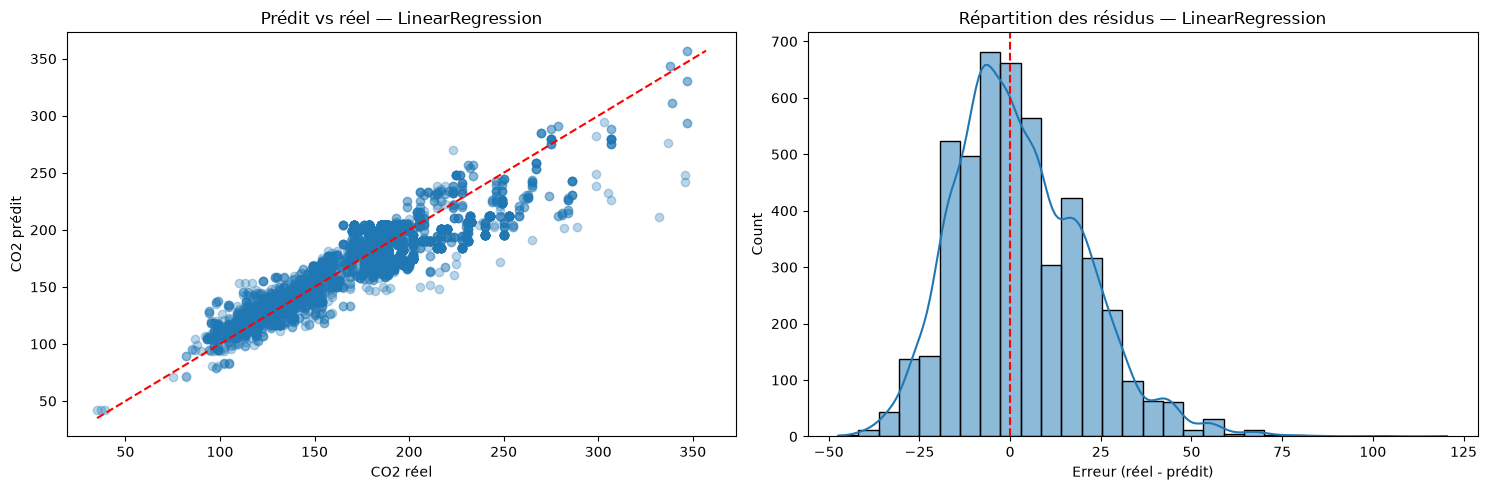

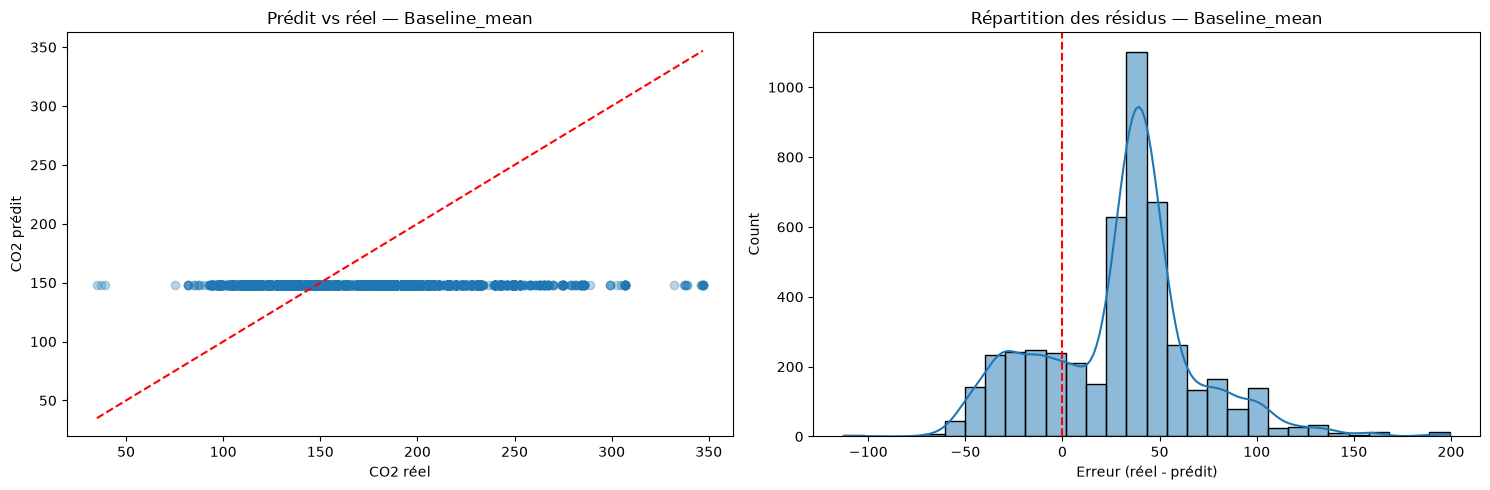

In [8]:
def plot_prediction_vs_real(model_name, pipe):
    pred = pipe.predict(X_test)
    residuals = y_test - pred
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].scatter(y_test, pred, alpha=0.3)
    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
    axes[0].set_xlabel("CO2 réel")
    axes[0].set_ylabel("CO2 prédit")
    axes[0].set_title(f"Prédit vs réel — {model_name}")
    sns.histplot(residuals, bins=30, ax=axes[1], kde=True)
    axes[1].axvline(0, color="red", linestyle="--")
    axes[1].set_title(f"Répartition des résidus — {model_name}")
    axes[1].set_xlabel("Erreur (réel - prédit)")
    plt.tight_layout()
    plt.show()

best_model_name = results_df["test_r2"].idxmax()
best_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", models[best_model_name])])
best_pipe.fit(X_train, y_train)
plot_prediction_vs_real(best_model_name, best_pipe)
baseline_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", models["Baseline_mean"])])
baseline_pipe.fit(X_train, y_train)
plot_prediction_vs_real("Baseline_mean", baseline_pipe)

## 8. Erreur par énergie et par famille

Le modèle ne se comporte pas de manière uniforme selon les catégories de moteur. Il faut vérifier s’il échoue davantage sur certaines énergies ou sur quelques très grandes familles. Cela fournit un signal métier plus utile que le seul R² global.

In [9]:
best_pred = best_pipe.predict(X_test)
err = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": best_pred,
    "abs_err": np.abs(y_test.values - best_pred),
    "energ": X_test["energ"].values,
    "famille": groups_test.values,
})
print("Erreur absolue moyenne par énergie")
print(err.groupby("energ")["abs_err"].mean().sort_values(ascending=False).head(10).round(2).to_string())
print("\nErreur absolue moyenne par famille")
print(err.groupby("famille")["abs_err"].mean().sort_values(ascending=False).head(10).round(2).to_string())

Erreur absolue moyenne par énergie
energ
ES/GN    38.12
ES/GP    36.93
GP/ES    27.04
GH       19.99
GN       19.70
GO       13.95
ES       13.78
EH       10.68
GN/ES     7.51
EE        5.52

Erreur absolue moyenne par famille
famille
AUDI | R8 COUPE                         84.67
INFINITI | QX50                         68.37
INFINITI | QX70                         65.94
MASERATI | GRANCABRIO MC                60.90
ROLLS ROYCE | PHANTOM DROPHEAD COUPE    53.62
LADA | 4X4                              50.92
NISSAN | MURANO                         50.87
PORSCHE | BOXSTER S                     49.34
AUDI | RS 6 AVANT                       47.42
DANGEL | SCUDO 4x4                      32.89


## 9. Interprétation des coefficients et importance des variables

Les coefficients de la régression linéaire et l’importance des variables du Random Forest permettent de comprendre le sens appris par le modèle. Il faut cependant rester prudent : l’importance n’est pas une preuve de causalité. Par ailleurs, la variable `puiss_admin` est historique et incorporait déjà des éléments très liés au CO2 ; elle doit donc être interprétée avec précaution.

In [10]:
lin_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", LinearRegression())])
lin_pipe.fit(X_train, y_train)
feature_names = lin_pipe.named_steps["preprocessor"].get_feature_names_out()
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lin_pipe.named_steps["model"].coef_,
}).sort_values("coefficient", key=lambda s: s.abs(), ascending=False)
print("Coefficients linéaires les plus forts en valeur absolue :")
print(coef_df.head(10).round(4).to_string(index=False))

rf_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", RandomForestRegressor(n_estimators=300, random_state=rnd_state, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_pipe.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)
print("\nImportance des variables du Random Forest :")
print(importance_df.head(10).round(4).to_string(index=False))

Coefficients linéaires les plus forts en valeur absolue :
                   feature  coefficient
          num__puiss_admin      65.1366
             cat__energ_GL     -62.9689
             cat__energ_EH      46.6560
            num__puiss_max     -43.7230
             cat__energ_EE     -42.2077
          cat__hybride_non      32.6772
          cat__hybride_oui     -32.6772
cat__typ_boite_nb_rapp_M 7      29.5175
          cat__energ_ES/GP      26.0925
             cat__energ_GH      25.8434

Importance des variables du Random Forest :
                   feature  importance
          num__puiss_admin      0.6912
      num__masse_ordma_min      0.1696
            num__puiss_max      0.0291
cat__typ_boite_nb_rapp_A 7      0.0254
             cat__energ_ES      0.0246
             cat__energ_EE      0.0131
          cat__hybride_non      0.0112
          cat__hybride_oui      0.0111
cat__typ_boite_nb_rapp_A 6      0.0077
             cat__energ_GO      0.0035


## 10. Comparaison avec un jeu de variables réduit

Pour vérifier l’apport de variables supplémentaires, on compare le modèle obtenu sur le jeu complet à un sous-ensemble très réduit composé uniquement de `puiss_admin` et `hybride`. Si le gain est réel, il montre que l’ajout d’informations comme la masse, la puissance maximale ou l’énergie améliore la qualité de la prédiction.

In [11]:
reduced_features = ["puiss_admin", "hybride"]
reduced_X = df[reduced_features].copy()
reduced_groups = df["famille"]
reduced_gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=rnd_state)
reduced_train_idx, reduced_test_idx = next(reduced_gss.split(reduced_X, y, reduced_groups))
reduced_X_train = reduced_X.iloc[reduced_train_idx].copy()
reduced_X_test = reduced_X.iloc[reduced_test_idx].copy()
reduced_y_train = y.iloc[reduced_train_idx].copy()
reduced_y_test = y.iloc[reduced_test_idx].copy()

reduced_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([ ("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()) ]), ["puiss_admin"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["hybride"]),
    ]
)
reduced_pipe = Pipeline(steps=[("preprocessor", reduced_preprocessor), ("model", LinearRegression())])
reduced_pipe.fit(reduced_X_train, reduced_y_train)
reduced_pred = reduced_pipe.predict(reduced_X_test)
reduced_metrics = {
    "r2": r2_score(reduced_y_test, reduced_pred),
    "rmse": np.sqrt(mean_squared_error(reduced_y_test, reduced_pred)),
    "mae": mean_absolute_error(reduced_y_test, reduced_pred),
}
print("Réduit (puiss_admin + hybride) :")
print(reduced_metrics)
print("\nComplet (meilleur modèle) :")
print({
    "r2": round(results_df.loc[best_model_name, "test_r2"], 4),
    "rmse": round(results_df.loc[best_model_name, "test_rmse"], 4),
    "mae": round(results_df.loc[best_model_name, "test_mae"], 4),
})

Réduit (puiss_admin + hybride) :
{'r2': -0.5690205955318073, 'rmse': np.float64(49.32898089035062), 'mae': 41.726336772584226}

Complet (meilleur modèle) :
{'r2': np.float64(0.7888), 'rmse': np.float64(18.098), 'mae': np.float64(14.0581)}


## 11. Synthèse de la chaîne complète

Question métier : peut-on prédire le CO2 d’un véhicule à partir de ses caractéristiques techniques ?
- X : puissance, masse, énergie, hybridation, transmission.
- y : `co2_mixte` en g/km.
- split : train/test par famille pour éviter la fuite entre variantes quasi identiques.
- prétraitement : imputation + standardisation + OneHot.
- baseline : `DummyRegressor(strategy='mean')`.
- modèles : régression linéaire, arbre de décision, Random Forest, éventuellement KNN.
- métriques : R², RMSE, MAE ; comparaison train/test et validation croisée groupée.
- interprétation : le meilleur modèle est retenu par sa généralisation, mais les variables doivent être interprétées avec prudence, notamment `puiss_admin` et les familles surreprésentées.
La conclusion finale est guidée par les résultats exécutés, non par une intuition. Le modèle doit améliorer la baseline de manière stable, tout en restant interprétable et sans fuite entre familles.